# YOLO CIFAR10: Fine-Tuned Teacher → Pruned Student → Logits Distillation (Classification)

This notebook runs a YOLOv8n-cls **classification** knowledge distillation flow on CIFAR10:
1. Load a **CIFAR10-fine-tuned** YOLOv8x-cls teacher (10-class head).
2. Instantiate a randomly-initialised YOLOv8m-cls student (no pruning).
3. Distill teacher logits into the student using CIFAR10 mini-batches (images + labels).
4. Evaluate teacher, finetuned-only (no KD) student, and distilled student on CIFAR10 validation set.


In [1]:
TEACHER_CHECKPOINT = "data/cifar10_yolov8x_cls/runs/yolov8x_cls_cifar10_finetune/weights/best.pt"
DEVICE = "cuda"
DATA_ROOT = "./data"

IMAGE_SIZE = 32
BATCH_SIZE = 128

KD_ALPHA = 0.6
KD_TEMPERATURE = 8.0
EPOCHS = 2
lr = 1e-5
WEIGHT_DECAY = 1e-4

seed = 42

STUDENT_FINETUNED_SAVE_PATH = "data/best_student_finetuned_5.pt"
KD_SAVE_PATH = "data/best_student_5.pt"


## Imports and setup

In [2]:
import copy
import random
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from ultralytics import YOLO

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root containing src/")

repo_root = find_repo_root(Path.cwd().resolve())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from chop.models.yolo.yolov8 import MaseYoloClassificationModel, patch_yolo

from mase_kd.core.losses import DistillationLossConfig, hard_label_ce_loss, soft_logit_kl_loss
from mase_kd.vision.yolo_kd import YOLOLogitsDistiller

print(f"Repo root: {repo_root}")
print(f"Using src path: {src_path}")


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Repo root: /workspace/mase-kd
Using src path: /workspace/mase-kd/src


In [3]:
if DEVICE == "cuda" and not torch.cuda.is_available():
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

torch.manual_seed(seed)
random.seed(seed)

Using device: cuda


## CIFAR10 image dataset and dataloaders

In [4]:
# Ultralytics trains YOLO on CIFAR10 with mean=(0,0,0), std=(1,1,1)
# Standard CIFAR10 augmentation pipeline to reduce overfitting.
cifar_transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.2)),
])
cifar_transform_eval = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root=DATA_ROOT, train=True, transform=cifar_transform_train, download=True)
val_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, transform=cifar_transform_eval, download=True)

# drop_last=True keeps batch size fixed for the FX-specialized pruned student graph.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

#print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")


## Load CIFAR10-fine-tuned teacher (YOLOv8n-cls, 10 classes)

In [5]:

# Two-step loading is necessary for two reasons:
# 1. Ultralytics .pt files are pickled objects (not plain state dicts), so YOLO() is the
#    safe deserializer. ultra_teacher.model.yaml is the only clean way to read `nc` (and
#    other arch params) before we can instantiate MaseYoloClassificationModel(nc=nc).
# 2. Once YOLO() has reconstructed the live model, ultra_teacher.model.state_dict() gives
#    a standard PyTorch state dict that maps 1:1 to MaseYoloClassificationModel's weights.
#    We need MaseYoloClassificationModel (not ultra_teacher.model directly) so that the
#    teacher's forward returns a flat [batch, nc] tensor; the raw ultralytics
#    ClassificationModel returns a structured tuple in train mode, which would cause
#    _flatten_logits to concatenate it into [batch, 2*nc].

ultra_teacher = YOLO(TEACHER_CHECKPOINT)
nc = ultra_teacher.model.yaml.get("nc", 10)

teacher_cls_model = MaseYoloClassificationModel(cfg="yolov8x-cls.yaml", nc=nc)
teacher_cls_model = patch_yolo(teacher_cls_model)
teacher_cls_model.load_state_dict(ultra_teacher.model.state_dict())
teacher_cls_model = teacher_cls_model.to(DEVICE)
teacher_cls_model.eval()

print(f"Loaded CIFAR10-fine-tuned teacher: {TEACHER_CHECKPOINT}")
print(f"Teacher num_classes (nc): {nc}")


Overriding model.yaml nc=1000 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1   1844480  ultralytics.nn.modules.conv.Conv             [320, 640, 3, 2]              
  6                  -1  6  13117440  ultralytics.nn.modules.block.C2f             [640, 640, 6, True]           
  7                  -1  1   7375360  ultralyt

## Build student model (YOLOv8m-cls, randomly initialised)


In [6]:
student_seed_cls_model = MaseYoloClassificationModel(cfg="yolov8m-cls.yaml", nc=nc)
student_seed_cls_model = patch_yolo(student_seed_cls_model)
student_cls_model = student_seed_cls_model.to(DEVICE)

# Snapshot of the uninitialised student before any training for baseline comparison.
baseline_no_train_model = copy.deepcopy(student_cls_model).to(DEVICE)
baseline_no_train_model.eval()

print("Student model (yolov8m-cls, randomly initialised) ready.")


Overriding model.yaml nc=1000 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   2655744  ultralyt

## Evaluate baseline student (no training)


In [7]:

import time

@torch.no_grad()
def evaluate_model_on_cifar10_val(model, loader, device):
    """Evaluate a model on the full validation loader. Returns top-1/top-5 accuracy, CE loss, and timing."""
    model.eval()
    batches = 0
    samples = 0
    total_forward_ms = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total_ce_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model.train()  # train mode → Classify head returns raw logits, not softmax
        outputs = model(images)
        model.eval()
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        outputs = YOLOLogitsDistiller._unwrap_classify_output(outputs)
        logits = YOLOLogitsDistiller._extract_logits_with_batch(outputs, images.shape[0])
        if logits is None or logits.numel() == 0:
            continue

        total_forward_ms += (t1 - t0) * 1000.0
        batches += 1
        samples += images.shape[0]

        max_label = int(labels.max().item())
        if logits.shape[1] > max_label:
            preds = logits.argmax(dim=1)
            correct_top1 += int((preds == labels).sum().item())
            k = min(5, logits.shape[1])
            top_k_indices = logits.topk(k, dim=1).indices
            correct_top5 += int(
                (top_k_indices == labels.unsqueeze(1)).any(dim=1).sum().item()
            )
            total_ce_loss += hard_label_ce_loss(logits, labels).item()

    return {
        "batches": batches,
        "samples": samples,
        "avg_forward_ms_per_batch": total_forward_ms / max(batches, 1),
        "top1_acc": correct_top1 / max(samples, 1),
        "top5_acc": correct_top5 / max(samples, 1),
        "avg_ce_loss": total_ce_loss / max(batches, 1),
    }

baseline_no_train_metrics = evaluate_model_on_cifar10_val(baseline_no_train_model, val_loader, DEVICE)
print(f"Student (no training, random init):")
print(
    f"  top1_acc={baseline_no_train_metrics['top1_acc']*100:.2f}% | "
    f"top5_acc={baseline_no_train_metrics['top5_acc']*100:.2f}% | "
    f"CE_loss={baseline_no_train_metrics['avg_ce_loss']:.4f} | "
    f"fwd_ms/batch={baseline_no_train_metrics['avg_forward_ms_per_batch']:.2f} | "
    f"samples={baseline_no_train_metrics['samples']}"
)


Student (no training, random init):
  top1_acc=8.88% | top5_acc=47.91% | CE_loss=2.3804 | fwd_ms/batch=101.78 | samples=9984


## Finetune and evaluate student (No Distillation)


In [8]:

# Fine-tune a copy of the student with CE loss only (no distillation).
student_finetuned_model = copy.deepcopy(baseline_no_train_model).to(DEVICE)
ft_optimizer = torch.optim.Adam(student_finetuned_model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

ft_loss_history = []
ft_top1_history = []
ft_top5_history = []
ft_val_top1_history = []  # per-epoch validation top-1
ft_val_top5_history = []  # per-epoch validation top-5
ft_val_loss_history = []  # per-epoch validation CE loss

best_ft_top1: float | None = None

for epoch in range(1, EPOCHS + 1):
    student_finetuned_model.train()
    total_loss = 0.0
    num_batches = len(train_loader)
    epoch_top1 = []

    for batch_idx, (images, labels) in enumerate(train_loader, start=1):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        ft_optimizer.zero_grad(set_to_none=True)

        outputs = student_finetuned_model(images)
        logits = YOLOLogitsDistiller._extract_logits_with_batch(outputs, images.shape[0])
        loss = hard_label_ce_loss(logits, labels)
        loss.backward()
        ft_optimizer.step()
        total_loss += loss.item()

        with torch.no_grad():
            n_classes = logits.shape[1]
            preds_top1 = logits.argmax(dim=1)
            top1 = float((preds_top1 == labels).float().mean().item())
            k = min(5, n_classes)
            top_k_indices = logits.topk(k, dim=1).indices
            top5 = float((top_k_indices == labels.unsqueeze(1)).any(dim=1).float().mean().item())

        ft_loss_history.append(loss.item())
        ft_top1_history.append(top1)
        ft_top5_history.append(top5)
        epoch_top1.append(top1)

        if batch_idx == 1 or batch_idx % 100 == 0 or batch_idx == num_batches:
            print(
                f"  Epoch {epoch}/{EPOCHS} | Batch {batch_idx:04d}/{num_batches} | "
                f"loss={loss.item():.6f} | top1={top1*100:.2f}% | top5={top5*100:.2f}%"
            )
    print(f"Epoch {epoch} avg train loss: {total_loss / num_batches:.6f}")

    # Per-epoch validation
    val_metrics = evaluate_model_on_cifar10_val(student_finetuned_model, val_loader, DEVICE)
    ft_val_top1_history.append(val_metrics["top1_acc"])
    ft_val_top5_history.append(val_metrics["top5_acc"])
    ft_val_loss_history.append(val_metrics["avg_ce_loss"])
    print(
        f"  Val: top1_acc={val_metrics['top1_acc']*100:.2f}% | "
        f"top5_acc={val_metrics['top5_acc']*100:.2f}% | "
        f"CE_loss={val_metrics['avg_ce_loss']:.4f}"
    )

    # Save best model based on validation top-1 accuracy.
    if best_ft_top1 is None or val_metrics["top1_acc"] > best_ft_top1:
        best_ft_top1 = val_metrics["top1_acc"]
        torch.save(student_finetuned_model.state_dict(), STUDENT_FINETUNED_SAVE_PATH)
        print(f"  [checkpoint] New best val_top1={val_metrics['top1_acc']:.6f} — model saved to '{STUDENT_FINETUNED_SAVE_PATH}'")

student_finetuned_model.load_state_dict(
    torch.load(STUDENT_FINETUNED_SAVE_PATH, weights_only=True), strict=False
)
print(f"Loaded best finetuned weights from '{STUDENT_FINETUNED_SAVE_PATH}' for evaluation.")

student_finetuned_metrics = evaluate_model_on_cifar10_val(student_finetuned_model, val_loader, DEVICE)
print(f"\nStudent (finetuned {EPOCHS} epochs, no KD):")
print(
    f"  top1_acc={student_finetuned_metrics['top1_acc']*100:.2f}% | "
    f"top5_acc={student_finetuned_metrics['top5_acc']*100:.2f}% | "
    f"CE_loss={student_finetuned_metrics['avg_ce_loss']:.4f} | "
    f"fwd_ms/batch={student_finetuned_metrics['avg_forward_ms_per_batch']:.2f} | "
    f"samples={student_finetuned_metrics['samples']}"
)


  Epoch 1/2 | Batch 0001/390 | loss=2.400888 | top1=7.03% | top5=50.00%
  Epoch 1/2 | Batch 0100/390 | loss=2.275900 | top1=10.94% | top5=56.25%
  Epoch 1/2 | Batch 0200/390 | loss=2.246510 | top1=17.19% | top5=66.41%
  Epoch 1/2 | Batch 0300/390 | loss=2.106192 | top1=16.41% | top5=76.56%
  Epoch 1/2 | Batch 0390/390 | loss=1.961260 | top1=32.81% | top5=82.03%
Epoch 1 avg train loss: 2.170917
  Val: top1_acc=26.23% | top5_acc=79.42% | CE_loss=2.0028
  [checkpoint] New best val_top1=0.262320 — model saved to 'data/best_student_finetuned_5.pt'
  Epoch 2/2 | Batch 0001/390 | loss=2.007060 | top1=29.69% | top5=77.34%
  Epoch 2/2 | Batch 0100/390 | loss=2.011153 | top1=26.56% | top5=79.69%
  Epoch 2/2 | Batch 0200/390 | loss=1.827727 | top1=36.72% | top5=85.16%
  Epoch 2/2 | Batch 0300/390 | loss=1.993531 | top1=24.22% | top5=84.38%
  Epoch 2/2 | Batch 0390/390 | loss=1.873699 | top1=36.72% | top5=80.47%
Epoch 2 avg train loss: 1.956320
  Val: top1_acc=33.03% | top5_acc=84.18% | CE_loss=1.

## Memory cleanup before distillation

In [9]:

import gc

# Free objects that are no longer needed before distillation.
for _var in ("ultra_teacher", "student_seed_cls_model",
             "baseline_no_train_model", "student_finetuned_model", "ft_optimizer"):
    if _var in globals():
        del globals()[_var]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1e6:.1f} MB allocated")
print("Memory cleanup done.")


GPU memory after cleanup: 492.1 MB allocated
Memory cleanup done.


## Distill teacher into pruned student on CIFAR10 images + labels

In [10]:

kd_config_cls = DistillationLossConfig(
    alpha=KD_ALPHA,
    temperature=KD_TEMPERATURE,
)

optimizer = torch.optim.Adam(student_cls_model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

distiller_cls = YOLOLogitsDistiller(
    teacher=teacher_cls_model,
    student=student_cls_model,
    kd_config=kd_config_cls,
    device=DEVICE,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_train_epochs=EPOCHS,
    eval_teacher=True,
)

train_history = distiller_cls.train(save_path=KD_SAVE_PATH)
loss_history     = train_history["train_total_loss"]
top1_history     = train_history["train_top1_acc"]
top5_history     = train_history["train_top5_acc"]
val_top1_history = train_history["val_top1_acc"]   # per-epoch validation top-1
val_top5_history = train_history["val_top5_acc"]   # per-epoch validation top-5
val_loss_history = train_history["val_loss"]        # per-epoch validation CE loss

# Restore best student weights before evaluation.
# strict=False: pruning masks are non-persistent buffers excluded from state_dict but
# already present and unchanged on this model instance, so only weights need restoring.
student_cls_model.load_state_dict(
    torch.load(KD_SAVE_PATH, weights_only=True), strict=False
)
print(f"Loaded best KD student weights from '{KD_SAVE_PATH}' for evaluation.")


Epoch 1/2
  Batch 0001/390 | total=5.619566 | hard=2.367036 | soft=7.787919 | top1=0.0781 | top5=0.4766
  Batch 0010/390 | total=5.323247 | hard=2.329721 | soft=7.318932 | top1=0.0703 | top5=0.6406
  Batch 0020/390 | total=5.449800 | hard=2.334994 | soft=7.526337 | top1=0.0938 | top5=0.5781
  Batch 0030/390 | total=5.277030 | hard=2.252607 | soft=7.293313 | top1=0.1953 | top5=0.6328
  Batch 0040/390 | total=5.322881 | hard=2.236779 | soft=7.380281 | top1=0.1719 | top5=0.6406
  Batch 0050/390 | total=5.354369 | hard=2.322832 | soft=7.375392 | top1=0.0859 | top5=0.5781
  Batch 0060/390 | total=5.398984 | hard=2.256347 | soft=7.494076 | top1=0.1094 | top5=0.6172
  Batch 0070/390 | total=4.961471 | hard=2.202982 | soft=6.800464 | top1=0.1953 | top5=0.6094
  Batch 0080/390 | total=5.289032 | hard=2.256221 | soft=7.310905 | top1=0.1250 | top5=0.6172
  Batch 0090/390 | total=5.300053 | hard=2.181820 | soft=7.378875 | top1=0.1641 | top5=0.6719
  Batch 0100/390 | total=5.776307 | hard=2.326496 

## Evaluation: teacher vs pruned-only vs distilled student (CIFAR10 validation)

In [11]:

# --- Training loss summary ---
if "loss_history" in globals() and len(loss_history) > 0:
    print(f"Recorded {len(loss_history)} KD training batches")
    print(f"  First loss: {loss_history[0]:.6f}")
    print(f"  Last loss:  {loss_history[-1]:.6f}")
    if top1_history and not all(isinstance(v, float) and v != v for v in top1_history):
        valid_top1 = [v for v in top1_history if v == v]  # filter NaN
        if valid_top1:
            print(f"  Final train top1: {valid_top1[-1]*100:.2f}%")
    if top5_history and not all(isinstance(v, float) and v != v for v in top5_history):
        valid_top5 = [v for v in top5_history if v == v]
        if valid_top5:
            print(f"  Final train top5: {valid_top5[-1]*100:.2f}%")
else:
    print("No training loss history found in current kernel session.")

# --- Evaluate teacher + distilled student via the distiller ---
print("\n--- CIFAR10 Validation Results ---\n")

eval_results = distiller_cls.evaluate()
teacher_metrics = eval_results.get("teacher")
student_metrics = eval_results["student"]
val_kd_loss = eval_results["val_kd_loss"]
kd_batches = eval_results["kd_batches"]

def _fmt_metrics(m: dict) -> str:
    return (
        f"  top1_acc={m['top1_acc']*100:.2f}% | "
        f"top5_acc={m['top5_acc']*100:.2f}% | "
        f"CE_loss={m['avg_ce_loss']:.4f} | "
        f"fwd_ms/batch={m['avg_forward_ms_per_batch']:.2f} | "
        f"samples={m['samples']}"
    )

# --- Print results ---
if teacher_metrics is not None:
    print(f"Teacher (fine-tuned on CIFAR10):")
    print(_fmt_metrics(teacher_metrics))

if "baseline_no_train_metrics" in globals() and baseline_no_train_metrics is not None:
    print(f"\nStudent (no training, random init):")
    print(_fmt_metrics(baseline_no_train_metrics))

if "student_finetuned_metrics" in globals() and student_finetuned_metrics is not None:
    print(f"\nStudent (finetuned {EPOCHS} epochs, no KD):")
    print(_fmt_metrics(student_finetuned_metrics))

print(f"\nDistilled student ({EPOCHS} epochs, alpha={KD_ALPHA}, T={KD_TEMPERATURE}):")
print(_fmt_metrics(student_metrics))

print(f"\nValidation KD loss (teacher vs distilled student, T={KD_TEMPERATURE}): "
      f"{val_kd_loss:.6f} over {kd_batches} batches")

# --- Summary table ---
print("\n--- Summary ---")
print(f"{'Model':<45} {'Top-1 Acc':>10} {'Top-5 Acc':>10} {'CE Loss':>10}")
print(f"{'─'*45} {'─'*10} {'─'*10} {'─'*10}")
if teacher_metrics is not None:
    print(f"{'Teacher (fine-tuned)':<45} {teacher_metrics['top1_acc']*100:>9.2f}% {teacher_metrics['top5_acc']*100:>9.2f}% {teacher_metrics['avg_ce_loss']:>10.4f}")
if "baseline_no_train_metrics" in globals() and baseline_no_train_metrics is not None:
    print(f"{'Student (no training, random init)':<45} {baseline_no_train_metrics['top1_acc']*100:>9.2f}% {baseline_no_train_metrics['top5_acc']*100:>9.2f}% {baseline_no_train_metrics['avg_ce_loss']:>10.4f}")
if "student_finetuned_metrics" in globals() and student_finetuned_metrics is not None:
    print(f"{'Student (finetuned, no KD)':<45} {student_finetuned_metrics['top1_acc']*100:>9.2f}% {student_finetuned_metrics['top5_acc']*100:>9.2f}% {student_finetuned_metrics['avg_ce_loss']:>10.4f}")
print(f"{'Distilled student (KD)':<45} {student_metrics['top1_acc']*100:>9.2f}% {student_metrics['top5_acc']*100:>9.2f}% {student_metrics['avg_ce_loss']:>10.4f}")


Recorded 780 KD training batches
  First loss: 5.619566
  Last loss:  3.923709
  Final train top1: 30.47%
  Final train top5: 84.38%

--- CIFAR10 Validation Results ---

Teacher (fine-tuned on CIFAR10):
  top1_acc=89.28% | top5_acc=99.61% | CE_loss=0.3165 | fwd_ms/batch=31.13 | samples=9984

Student (no training, random init):
  top1_acc=8.88% | top5_acc=47.91% | CE_loss=2.3804 | fwd_ms/batch=101.78 | samples=9984

Student (finetuned 2 epochs, no KD):
  top1_acc=33.03% | top5_acc=84.18% | CE_loss=1.8364 | fwd_ms/batch=11.01 | samples=9984

Distilled student (2 epochs, alpha=0.6, T=8.0):
  top1_acc=36.07% | top5_acc=87.35% | CE_loss=1.8017 | fwd_ms/batch=11.31 | samples=9984

Validation KD loss (teacher vs distilled student, T=8.0): 5.341665 over 78 batches

--- Summary ---
Model                                          Top-1 Acc  Top-5 Acc    CE Loss
───────────────────────────────────────────── ────────── ────────── ──────────
Teacher (fine-tuned)                              89.28%  

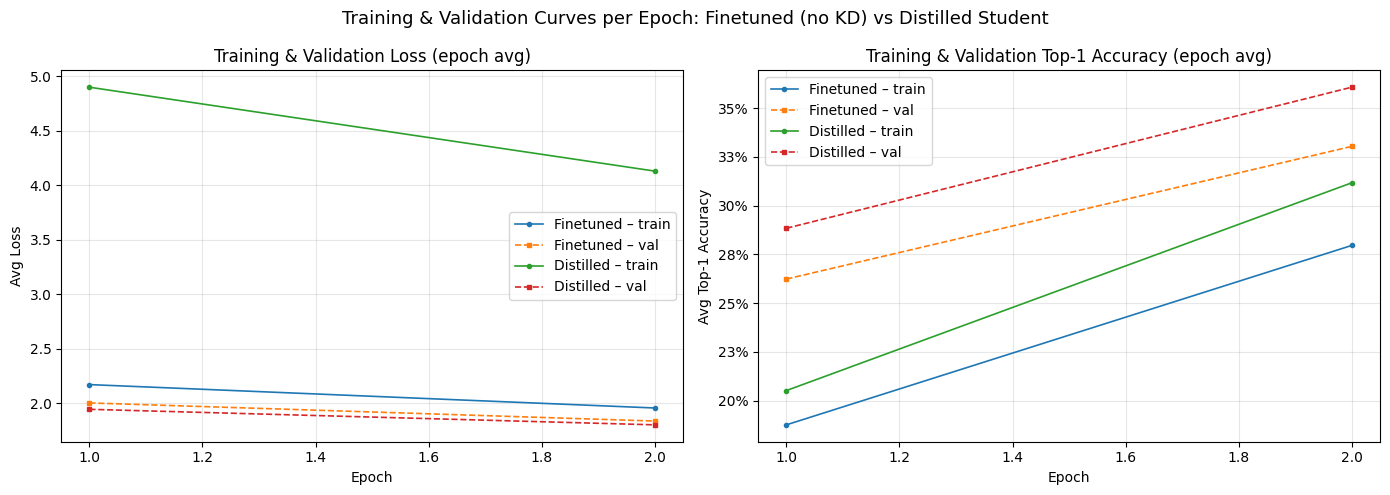

In [12]:

import matplotlib.pyplot as plt
import math

def _epoch_avg(hist: list[float], n_epochs: int) -> list[float]:
    """Average a per-batch history into per-epoch values."""
    if not hist or n_epochs == 0:
        return []
    batches_per_epoch = len(hist) // n_epochs
    if batches_per_epoch == 0:
        return []
    return [
        sum(hist[e * batches_per_epoch : (e + 1) * batches_per_epoch]) / batches_per_epoch
        for e in range(n_epochs)
    ]

def _epoch_avg_no_nan(hist: list[float], n_epochs: int) -> list[float]:
    """Average a per-batch history into per-epoch values, skipping NaN entries."""
    if not hist or n_epochs == 0:
        return []
    batches_per_epoch = len(hist) // n_epochs
    if batches_per_epoch == 0:
        return []
    result = []
    for e in range(n_epochs):
        chunk = [v for v in hist[e * batches_per_epoch : (e + 1) * batches_per_epoch]
                 if not math.isnan(v)]
        result.append(sum(chunk) / len(chunk) if chunk else float("nan"))
    return result

epochs_axis = list(range(1, EPOCHS + 1))

# Per-batch train histories averaged to per-epoch
ft_loss_epoch  = _epoch_avg(ft_loss_history, EPOCHS)
kd_loss_epoch  = _epoch_avg(loss_history, EPOCHS)
ft_top1_epoch  = _epoch_avg_no_nan(ft_top1_history, EPOCHS)
kd_top1_epoch  = _epoch_avg_no_nan(top1_history, EPOCHS)

# Validation histories are already per-epoch (one value per epoch)
ft_val_loss_epoch  = ft_val_loss_history
ft_val_top1_epoch  = ft_val_top1_history
kd_val_loss_epoch  = val_loss_history
kd_val_top1_epoch  = val_top1_history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training & Validation Curves per Epoch: Finetuned (no KD) vs Distilled Student", fontsize=13)

# --- Loss curve ---
ax = axes[0]
ax.plot(epochs_axis, ft_loss_epoch,     label="Finetuned – train", marker="o", markersize=3, linewidth=1.2)
ax.plot(epochs_axis, ft_val_loss_epoch, label="Finetuned – val",   marker="s", markersize=3, linewidth=1.2, linestyle="--")
ax.plot(epochs_axis, kd_loss_epoch,     label="Distilled – train", marker="o", markersize=3, linewidth=1.2)
ax.plot(epochs_axis, kd_val_loss_epoch, label="Distilled – val",   marker="s", markersize=3, linewidth=1.2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg Loss")
ax.set_title("Training & Validation Loss (epoch avg)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Top-1 accuracy curve ---
ax = axes[1]
ax.plot(epochs_axis, ft_top1_epoch,     label="Finetuned – train", marker="o", markersize=3, linewidth=1.2)
ax.plot(epochs_axis, ft_val_top1_epoch, label="Finetuned – val",   marker="s", markersize=3, linewidth=1.2, linestyle="--")
ax.plot(epochs_axis, kd_top1_epoch,     label="Distilled – train", marker="o", markersize=3, linewidth=1.2)
ax.plot(epochs_axis, kd_val_top1_epoch, label="Distilled – val",   marker="s", markersize=3, linewidth=1.2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg Top-1 Accuracy")
ax.set_title("Training & Validation Top-1 Accuracy (epoch avg)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
